# Product Sales Prediction - Linear Regression (OLS)

## Bài toán
Dự đoán **doanh số bán lẻ** (`sales_amount_log`) của từng giao dịch dựa trên thông tin sản phẩm, khách hàng và giao dịch.

### Mục tiêu
Xây dựng mô hình **Linear Regression** bằng phương pháp OLS (Ordinary Least Squares) — **không dùng thư viện có sẵn** — để học cách mô hình tuyến tính hoạt động ở cấp độ toán học.

### Hướng giải quyết

| Bước | Nội dung |
|------|----------|
| 1 | Load dữ liệu đã xử lý, tách X / y |
| 2 | Xây dựng class `LinearRegressionOLS` giải Normal Equation |
| 3 | Fit model trên tập train |
| 4 | Dự đoán trên tập test, đánh giá bằng MSE / RMSE / MAE / R² |

# Model: Linear Regression — OLS 

**Input:** 79 features đã xử lý sẵn  
**Output:** `sales_amount_log`  
**Phương pháp:** Ordinary Least Squares — giải Normal Equation, không dùng thư viện

**Normal Equation:**
$$\theta = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T y \quad \text{với } \tilde{X} = [\mathbf{1} \;|\; X]$$

**Dự đoán:**
$$\hat{y} = X w + b$$

## Agenda

| # | Phase | Nội dung |
|---|-------|----------|
| 1 | [Load Dataset](#Phase-1-—-Load-&-Prepare-Data) | Đọc CSV, tách X / y thành numpy array |
| 2 | [Model & Metrics](#Phase-2-—-Định-nghĩa-mô-hình) | Class `LinearRegressionOLS` + hàm MSE, RMSE, MAE, R² |
| 3 | [Training](#Phase-3-—-Huấn-luyện-mô-hình) | Fit model — giải Normal Equation một lần duy nhất |
| 4 | [Evaluation](#Phase-4-—-Đánh-giá-&-Báo-cáo-kết-quả) | Kết quả metrics + visualize |

## [Phase 1 — Load Dataset]
### Dữ liệu

**Nguồn:** Dataset bán lẻ tổng hợp, đã được tiền xử lý sẵn và lưu trong 'retail_train_80.csv' và 'retail_test_20.csv'.

**Đặc trưng:**

| | Train | Test |
|-|-------|------|
| Số mẫu | 96,000 | 24,000 |
| Số features | 79 | 79 |
| Missing values | 0 | 0 |

**Phân loại features (79 features):**


| Nhóm feature | Số lượng | Ví dụ |
|---|---|---|
| Continuous | 8 | `unit_price`, `discount_pct`, `qty_roll_mean_30d`, ngày/tháng/năm giao dịch |
| One-hot encoded | 71 | tên sản phẩm, danh mục, thương hiệu, giới tính, phân khúc KH, kênh bán, vùng, thanh toán |

**Target:** `sales_amount_log` — log-transform của doanh số thực.

In [39]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# LOAD DATASET

train_df = pd.read_csv("retail_train_80.csv")
test_df = pd.read_csv("retail_test_20.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(96000, 80)
(24000, 80)


,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,qty_roll_mean_30d,customer_gender_Female,customer_gender_Male,customer_gender_Other,customer_segment_Loyal,customer_segment_New,...,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,-0.691685,0,-0.541627,1,-14.478986,0,1,0,0,0,...,0,0,0,0,0,1,2024,1,1,0
1,0.064785,15,0.538838,3,-14.478986,0,0,1,0,1,...,0,1,0,0,0,0,2024,1,1,0
2,-0.121140,5,-0.136904,4,-14.478986,1,0,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
3,0.064785,0,0.024365,1,-14.478986,0,1,0,0,0,...,1,0,0,0,1,0,2024,1,1,0
4,-0.121140,0,-0.087266,3,-14.478986,0,1,0,0,0,...,1,0,0,0,0,1,2024,1,1,0


In [41]:
# DATA PREPARATION: tách X, y và convert sang numpy array

target = "sales_amount_log"
feature_names = train_df.drop(columns=[target]).columns

X_train = train_df[feature_names].values.astype(float)
y_train = train_df[target].values.astype(float)

X_test = test_df.reindex(columns=feature_names).values.astype(float)
y_test = test_df[target].values.astype(float)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (96000, 79), y_train: (96000,)
X_test:  (24000, 79),  y_test:  (24000,)


## [Phase 2 — Định nghĩa mô hình]

### Linear Regression (OLS)

**Công thức dự đoán:**
$$\hat{y} = Xw + b$$

Bằng cách thêm cột bias vào X (bias trick), ta gộp `b` vào `w`:
$$\hat{y} = \tilde{X}\theta \quad \text{với } \tilde{X} = [1 \; | \; X], \; \theta = [b, w_1, w_2, \ldots]^T$$

**Normal Equation (OLS):**
$$\theta = (\tilde{X}^T \tilde{X})^{-1} \tilde{X}^T y$$

Đây là nghiệm **tối ưu toàn cục** — minimizes MSE trực tiếp, không cần iterate.

In [42]:
class LinearRegressionOLS:
    """
    Linear Regression solved via Ordinary Least Squares (Normal Equation).
    No learning rate, no epochs — exact closed-form solution.

    Normal Equation: theta = (X_aug^T X_aug)^{-1} X_aug^T y
    Implemented with lstsq for numerical stability.
    """

    def __init__(self):
        self.weights = None   # coefficients for each feature
        self.bias = None      # intercept term

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Thêm cột 1 vào đầu để gộp bias vào theta (bias trick)
        ones = np.ones((n_samples, 1))
        X_aug = np.hstack([ones, X])  # shape: (n, 1 + n_features)

        # Giải Normal Equation: theta = (X^T X)^{-1} X^T y
        # Dùng lstsq thay vì inv() để ổn định khi X^T X gần singular
        theta, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)

        self.bias    = theta[0]
        self.weights = theta[1:]

        print(f"✓ OLS fit complete")
        print(f"  bias    = {self.bias:.6f}")
        print(f"  weights: shape={self.weights.shape}, "
              f"min={self.weights.min():.4f}, max={self.weights.max():.4f}")

    def predict(self, X):
        return X @ self.weights + self.bias


### Các hàm đánh giá

| Metric | Công thức | Ý nghĩa |
|--------|-----------|---------|
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | Sai số bình phương trung bình |
| **RMSE** | $\sqrt{MSE}$ | Sai số trung bình cùng đơn vị với target |
| **MAE** | $\frac{1}{n}\sum\|y - \hat{y}\|$ | Sai số tuyệt đối trung bình |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Tỷ lệ phương sai được giải thích bởi mô hình |

In [43]:
# Evaluation Metrics 

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

## Phase 3 — Huấn luyện mô hình

In [44]:
# Train Model (OLS — no hyperparameters needed)

model = LinearRegressionOLS()

print("Fitting OLS model...")
model.fit(X_train, y_train)

Fitting OLS model...
✓ OLS fit complete
  bias    = 1.625597
  weights: shape=(79,), min=-0.5193, max=0.8585


## Phase 4 — Đánh giá & Báo cáo kết quả



In [45]:
# Step 5.1 - Prediction
train_predictions = model.predict(X_train)
predictions       = model.predict(X_test)

In [46]:
# Step 5.1.1 - Save test labels and predictions to a new file

test_df_out = test_df.copy()
test_df_out = test_df_out.drop(columns=["y_test", "y_pred"], errors="ignore")
test_df_out["y_test"] = y_test
test_df_out["y_pred"] = predictions

output_file = "retail_test_20_with_predictions.csv"
test_df_out.to_csv(output_file, index=False)
print(f"Saved {len(test_df_out)} rows to {output_file}")

Saved 24000 rows to retail_test_20_with_predictions.csv


In [47]:
# Step 5.2 - Evaluation Results

results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R² train", "R² test"],
    "Value": [
        mse(y_test, predictions),
        rmse(y_test, predictions),
        mae(y_test, predictions),
        r2_score(y_train, train_predictions),
        r2_score(y_test, predictions),
    ]
})

results

,Metric,Value
0,MSE,0.302716
1,RMSE,0.550196
2,MAE,0.449490
3,R² train,0.698721
4,R² test,0.697060


### Kết quả metrics

| Metric | Giá trị | Diễn giải |
|--------|---------|-----------|
| **MSE** | ~0.303 | Sai số bình phương trung bình trên tập test |
| **RMSE** | ~0.550 | Sai số trung bình ~0.55 đơn vị log-sales |
| **MAE** | ~0.449 | Sai số tuyệt đối trung bình ~0.45 đơn vị log-sales |
| **R² (Train)** | ~0.699 | Model giải thích ~69.9% phương sai trên train |
| **R² (Test)** | ~0.697 | Model giải thích ~69.7% phương sai trên test |

### Phân tích kết quả

**Điểm mạnh:**
- **Không overfitting:** Train R² ≈ Test R² → mô hình tổng quát tốt
- **Nghiệm tối ưu:** OLS đảm bảo đây là nghiệm tốt nhất có thể với Linear Regression

**Giới hạn:**
- **R² ≈ 0.697:** Còn ~30% phương sai chưa được giải thích — quan hệ phi tuyến mà Linear Regression không nắm bắt được

### Kết luận

OLS Linear Regression đạt **R² ≈ 0.697**, cho nghiệm tối ưu toàn cục trong không gian tuyến tính.

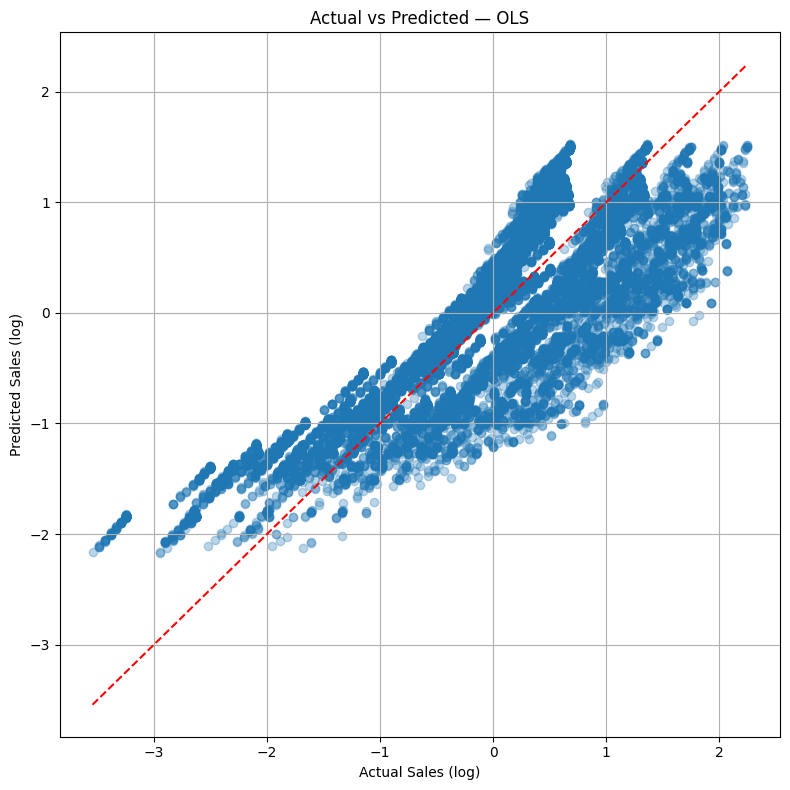

In [48]:
# Step 5.3 - Actual vs Predicted

plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales (log)")
plt.ylabel("Predicted Sales (log)")
plt.title("Actual vs Predicted — OLS")
plt.grid(True)
plt.tight_layout()
plt.show()

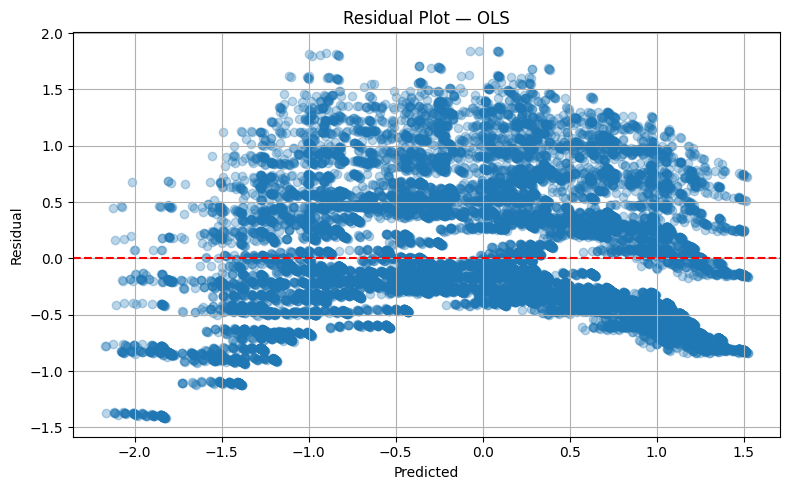

In [49]:
# Step 5.4 - Residual Plot

residuals = y_test - predictions

plt.figure(figsize=(8, 5))
plt.scatter(predictions, residuals, alpha=0.3)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot — OLS")
plt.grid(True)
plt.tight_layout()
plt.show()